In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

# Synthetic aviation parts dataset with realistic noise
data = {
    'material_type': np.random.choice(
        ['SP', 'T', 'C', 'M', 'N'], n,
        p=[0.35, 0.15, 0.25, 0.15, 0.10]
    ),
    'has_pma': np.random.choice([0, 1], n, p=[0.7, 0.3]),
    'is_tool': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'is_fixed_asset': np.random.choice([0, 1], n, p=[0.8, 0.2]),
    'ata_chapter': np.random.choice(
        ['00-00', '32-00', '49-00', '72-00', '97-97', '99-01'], n
    ),
    'sales_price_sar': np.round(np.random.exponential(scale=50, size=n), 2),
    'weight_kg': np.round(np.random.exponential(scale=4, size=n), 2),
}

df = pd.DataFrame(data)


In [2]:

# Same scoring logic as before
def classify_repairable(row):
    score = 0
    if row['sales_price_sar'] > 40:
        score += 1
    if row['has_pma'] == 1:
        score += 1
    if row['material_type'] in ['C', 'SP']:
        score += 1
    if row['is_tool'] == 1:
        score -= 2
    return 1 if score >= 2 else 0

df['is_repairable'] = df.apply(classify_repairable, axis=1)

# --- ADD REALISTIC NOISE ---

# 1. Label noise: 8% of labels get randomly flipped 
#    (simulates human inconsistency in real classification work)
np.random.seed(7)
noise_mask = np.random.random(n) < 0.08
df.loc[noise_mask, 'is_repairable'] = 1 - df.loc[noise_mask, 'is_repairable']

# 2. Missing data: 5% of PMA values are unknown (common in real systems)
missing_mask = np.random.random(n) < 0.05
df.loc[missing_mask, 'has_pma'] = np.nan

# 3. Fill missing PMA with a realistic default (most common value)
df['has_pma'] = df['has_pma'].fillna(df['has_pma'].mode()[0])

print("Realistic dataset created!")
print(f"Noise introduced: {noise_mask.sum()} labels flipped ({noise_mask.sum()/n:.1%})")
print(f"Missing data simulated: {missing_mask.sum()} PMA values were missing and imputed")
print("\nNew label distribution:")
print(df['is_repairable'].value_counts())
df.head()

Realistic dataset created!
Noise introduced: 40 labels flipped (8.0%)
Missing data simulated: 25 PMA values were missing and imputed

New label distribution:
0    316
1    184
Name: is_repairable, dtype: int64


,material_type,has_pma,is_tool,is_fixed_asset,ata_chapter,sales_price_sar,weight_kg,is_repairable
0,T,0.0,0,0,72-00,14.89,2.62,1
1,N,0.0,0,0,49-00,3.07,4.34,0
2,C,0.0,1,0,72-00,46.29,0.50,0
3,C,1.0,0,0,99-01,58.01,1.36,1
4,SP,0.0,0,0,32-00,6.08,2.03,0


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# --- Define which columns are which type ---
categorical_cols = ['material_type', 'ata_chapter']
numerical_cols   = ['has_pma', 'is_tool', 'is_fixed_asset', 'sales_price_sar', 'weight_kg']

# --- Build the preprocessor ---
# OneHotEncoder for categorical: no artificial numeric order imposed
# passthrough for numerical: already numbers, no change needed
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numerical_cols)
])

# --- Define the three models ---
models = {
    'Logistic Regression':      LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':             RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Hist Gradient Boosting':   HistGradientBoostingClassifier(random_state=42)
}

# --- Prepare data ---
X = df.drop('is_repairable', axis=1)
y = df['is_repairable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Setup complete.")
print(f"Training set: {len(X_train)} parts")
print(f"Test set:     {len(X_test)} parts")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Setup complete.
Training set: 400 parts
Test set:     100 parts

Class distribution in training set:
0    253
1    147
Name: is_repairable, dtype: int64


In [4]:
# --- Train and evaluate all three models ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print("=" * 60)
print("MODEL COMPARISON WITH CROSS-VALIDATION")
print("=" * 60)

for name, model in models.items():
    
    # Build full pipeline: preprocessing + model
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Cross-validation on training data (5 folds)
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=['f1_weighted', 'recall_macro', 'precision_macro'],
        return_train_score=False
    )
    
    # Train on full training set and test on held-out test set
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store results
    results[name] = {
        'pipeline': pipe,
        'y_pred': y_pred,
        'cv_f1_mean': cv_results['test_f1_weighted'].mean(),
        'cv_f1_std': cv_results['test_f1_weighted'].std(),
        'cv_recall_mean': cv_results['test_recall_macro'].mean(),
        'test_accuracy': test_accuracy,
        'test_f1': test_f1
    }
    
    # Print summary for this model
    print(f"\n{name}")
    print("-" * 40)
    print(f"  CV F1 (mean ± std):  {cv_results['test_f1_weighted'].mean():.3f} ± {cv_results['test_f1_weighted'].std():.3f}")
    print(f"  CV Recall (mean):    {cv_results['test_recall_macro'].mean():.3f}")
    print(f"  Test Accuracy:       {test_accuracy:.1%}")
    print(f"  Test F1:             {test_f1:.3f}")

print("\n" + "=" * 60)
print("DETAILED REPORT — BEST MODEL")

# Find best model by CV F1
best_name = max(results, key=lambda x: results[x]['cv_f1_mean'])
print(f"Best model: {best_name}")
print("=" * 60)
print(classification_report(
    y_test,
    results[best_name]['y_pred'],
    target_names=['Unrepairable', 'Repairable']
))

MODEL COMPARISON WITH CROSS-VALIDATION

Logistic Regression
----------------------------------------
  CV F1 (mean ± std):  0.825 ± 0.032
  CV Recall (mean):    0.833
  Test Accuracy:       77.0%
  Test F1:             0.774

Random Forest
----------------------------------------
  CV F1 (mean ± std):  0.891 ± 0.023
  CV Recall (mean):    0.875
  Test Accuracy:       88.0%
  Test F1:             0.877

Hist Gradient Boosting
----------------------------------------
  CV F1 (mean ± std):  0.875 ± 0.026
  CV Recall (mean):    0.866
  Test Accuracy:       82.0%
  Test F1:             0.820

DETAILED REPORT — BEST MODEL
Best model: Random Forest
              precision    recall  f1-score   support

Unrepairable       0.87      0.95      0.91        63
  Repairable       0.90      0.76      0.82        37

    accuracy                           0.88       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.88      0.88      0.88       100



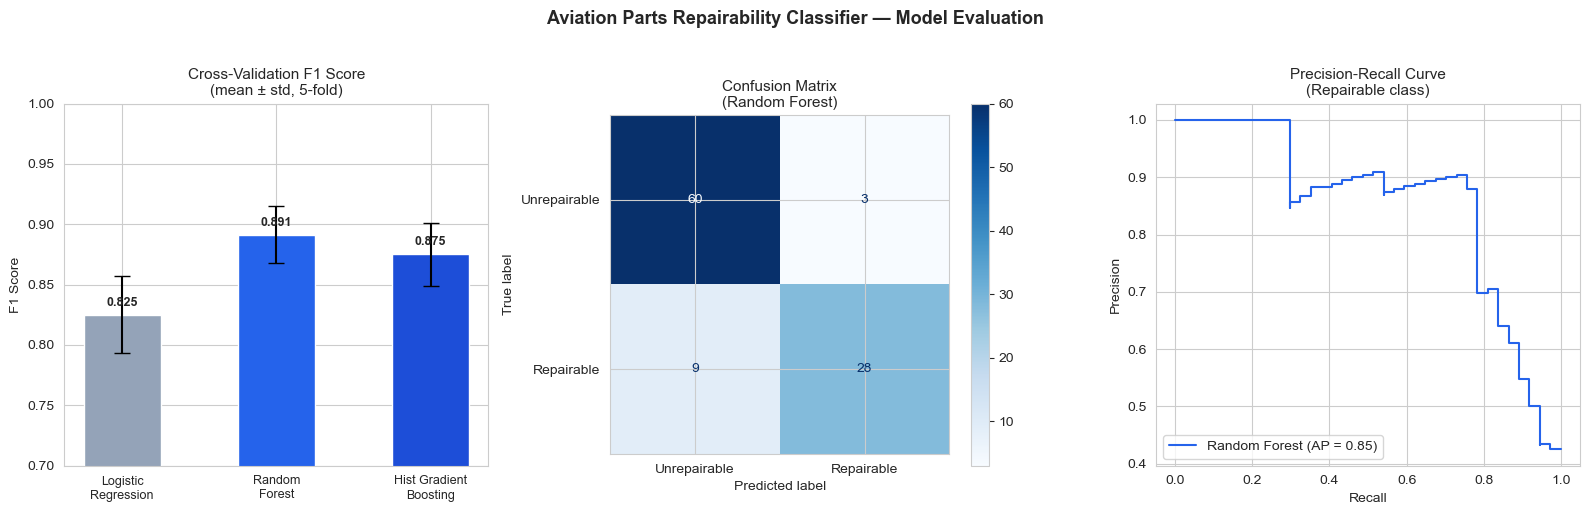

Charts saved as model_evaluation.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import PrecisionRecallDisplay
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# --- Chart 1: CV F1 Comparison ---
ax1 = fig.add_subplot(gs[0])
model_names = list(results.keys())
cv_means = [results[m]['cv_f1_mean'] for m in model_names]
cv_stds  = [results[m]['cv_f1_std'] for m in model_names]
colors = ['#94a3b8', '#2563eb', '#1d4ed8']

bars = ax1.bar(model_names, cv_means, yerr=cv_stds,
               capsize=6, color=colors, edgecolor='white', width=0.5)
ax1.set_ylim(0.7, 1.0)
ax1.set_title("Cross-Validation F1 Score\n(mean ± std, 5-fold)", fontsize=11)
ax1.set_ylabel("F1 Score")
ax1.set_xticklabels(
    ['Logistic\nRegression', 'Random\nForest', 'Hist Gradient\nBoosting'],
    fontsize=9
)
for bar, mean in zip(bars, cv_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Chart 2: Confusion Matrix (Best Model) ---
ax2 = fig.add_subplot(gs[1])
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    results[best_name]['y_pred'],
    display_labels=['Unrepairable', 'Repairable'],
    cmap='Blues',
    ax=ax2
)
ax2.set_title(f"Confusion Matrix\n({best_name})", fontsize=11)

# --- Chart 3: Precision-Recall Curve (Best Model) ---
ax3 = fig.add_subplot(gs[2])
best_pipe = results[best_name]['pipeline']
y_scores = best_pipe.predict_proba(X_test)[:, 1]

PrecisionRecallDisplay.from_predictions(
    y_test, y_scores,
    name=best_name,
    ax=ax3,
    color='#2563eb'
)
ax3.set_title("Precision-Recall Curve\n(Repairable class)", fontsize=11)
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")

plt.suptitle("Aviation Parts Repairability Classifier — Model Evaluation", 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Charts saved as model_evaluation.png")